In [2]:
import sys
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict, Counter

warnings.filterwarnings('ignore', category=FutureWarning)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'validation' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from annotator.eval.eval import (
    load_detections_as_moments,
    compute_detection_metrics,
    filter_moments_by_type,
)
from annotator.core.utils import (
    load_ground_truth, load_split_ids, EXAMPLE_CONV_IDS,
    compute_iou, merge_overlapping_ranges,
)

# Detection

Loaded detections: detections_anthropic_scaffolding.json
Loaded detections: detections_anthropic_rapport.json
✓ anthropic (train): 102 conversations
Loaded detections: detections_anthropic_test_scaffolding.json
Loaded detections: detections_anthropic_test_rapport.json
✓ anthropic (test): 105 conversations
Loaded detections: detections_gemini_25_pro_test_scaffolding.json
Loaded detections: detections_gemini_25_pro_test_rapport.json
✓ gemini-2.5-pro (test): 105 conversations
Loaded detections: detections_gemini_35_flash_test_scaffolding.json
Loaded detections: detections_gemini_35_flash_test_rapport.json
✓ gemini-3.5-flash (test): 105 conversations
Loaded detections: detections_openai_test_scaffolding.json
Loaded detections: detections_openai_test_rapport.json
✓ openai (test): 105 conversations


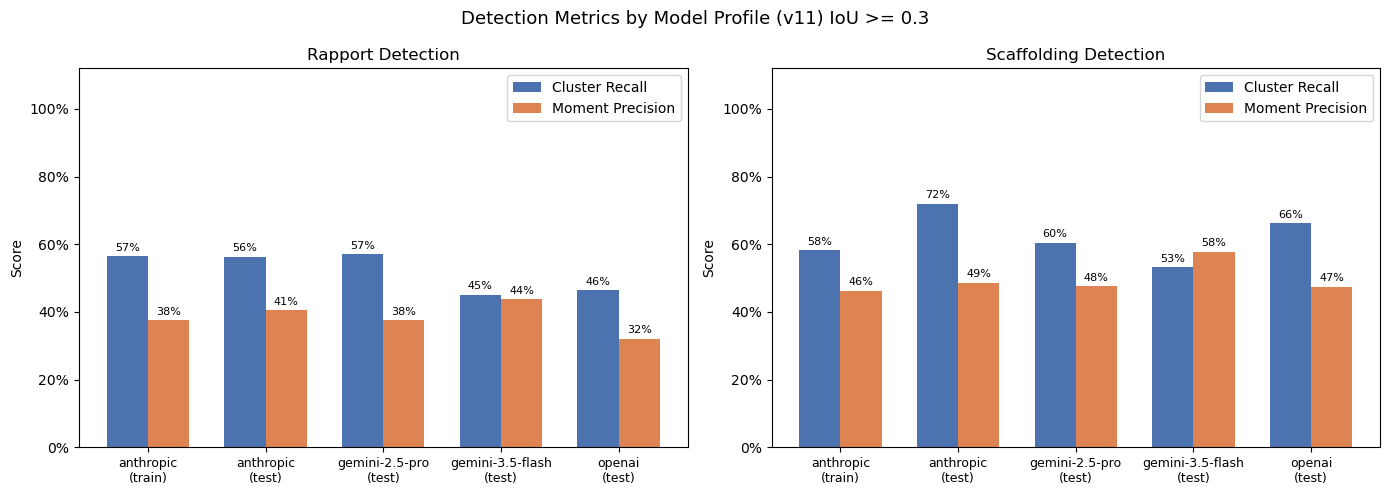

In [3]:
VERSION = "v11"
ANN_TYPES = ["rapport", "scaffolding"]

PROFILES = [
    dict(label="anthropic\n(train)",        profile="anthropic",       split="train"),
    dict(label="anthropic\n(test)",         profile="anthropic",       split="test"),
    dict(label="gemini-2.5-pro\n(test)",    profile="gemini_25_pro",   split="test"),
    dict(label="gemini-3.5-flash\n(test)",  profile="gemini_35_flash", split="test"),
    dict(label="openai\n(test)",            profile="openai",          split="test"),
]

ground_truth = load_ground_truth()

# ── Compute detection metrics per profile and annotation type ──────────────
det_metrics = {}  # label -> ann_type -> metrics dict

for p in PROFILES:
    split_ids = load_split_ids(p["split"])
    gt_convs = {cid: cd for cid, cd in ground_truth["conversations"].items()
                if cid in split_ids}

    llm_moments = load_detections_as_moments(VERSION, profile=p["profile"], split=p["split"])
    if llm_moments is None:
        print(f"SKIP (no results): {p['label'].replace(chr(10), ' ')}")
        continue

    eval_ids = (set(gt_convs.keys()) & set(llm_moments.keys())) - EXAMPLE_CONV_IDS

    human_by_conv, llm_by_conv = {}, {}
    for cid in eval_ids:
        human = gt_convs[cid]["key_moments"]
        human_types = {m.get("annotation_type") for m in human}
        human_by_conv[cid] = human
        llm_by_conv[cid] = [m for m in llm_moments.get(cid, [])
                            if m.get("annotation_type") in human_types]

    det_metrics[p["label"]] = {
        ann_type: compute_detection_metrics(
            filter_moments_by_type(human_by_conv, ann_type),
            filter_moments_by_type(llm_by_conv, ann_type),
        )
        for ann_type in ANN_TYPES
    }
    print(f"✓ {p['label'].replace(chr(10), ' ')}: {len(eval_ids)} conversations")

# ── Plot ───────────────────────────────────────────────────────────────────
labels = list(det_metrics.keys())
x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ann_type in zip(axes, ANN_TYPES):
    recalls    = [det_metrics[l][ann_type]["cluster_recall"]   for l in labels]
    precisions = [det_metrics[l][ann_type]["moment_precision"] for l in labels]

    bars_r = ax.bar(x - width / 2, recalls,    width, label="Cluster Recall",   color="#4C72B0")
    bars_p = ax.bar(x + width / 2, precisions, width, label="Moment Precision", color="#DD8452")

    for bar in list(bars_r) + list(bars_p):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f"{h:.0%}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Score")
    ax.set_title(f"{ann_type.capitalize()} Detection")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend()

plt.suptitle("Detection Metrics by Model Profile (v11) IoU >= 0.3", fontsize=13)
plt.tight_layout()
plt.show()

The plot below isn't that amazing but I was just curious...

Loaded detections: detections_anthropic_scaffolding.json
Loaded detections: detections_anthropic_rapport.json
Loaded detections: detections_anthropic_test_scaffolding.json
Loaded detections: detections_anthropic_test_rapport.json
Loaded detections: detections_gemini_25_pro_test_scaffolding.json
Loaded detections: detections_gemini_25_pro_test_rapport.json
Loaded detections: detections_gemini_35_flash_test_scaffolding.json
Loaded detections: detections_gemini_35_flash_test_rapport.json
Loaded detections: detections_openai_test_scaffolding.json
Loaded detections: detections_openai_test_rapport.json


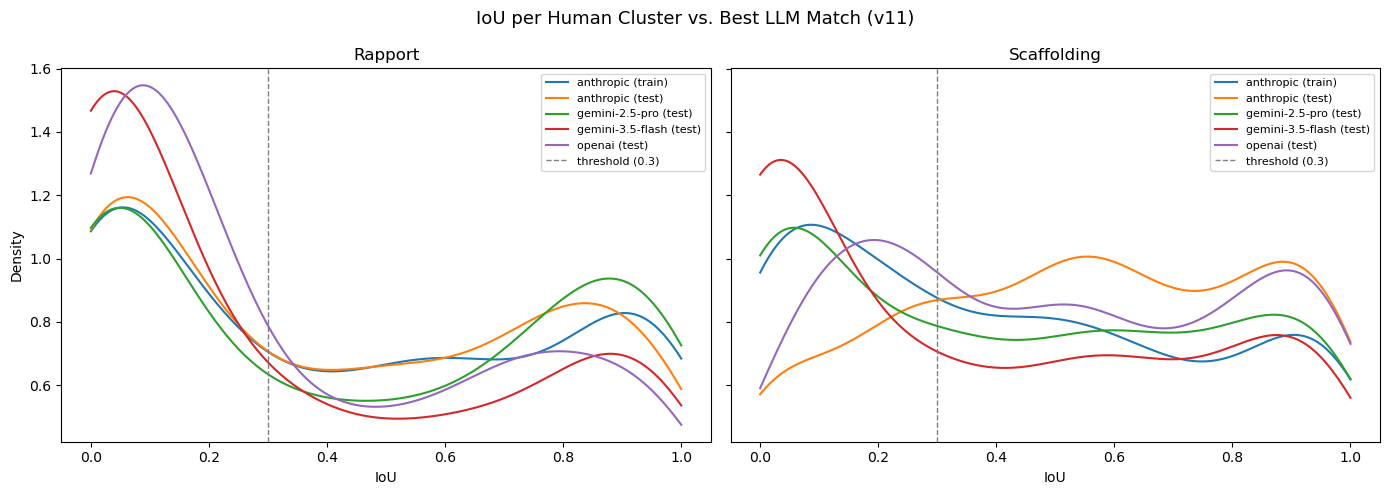

In [4]:
def collect_cluster_ious(human_by_conv, llm_by_conv):
    """For each human cluster, return the IoU with its best-matching LLM moment (0 if none)."""
    ious = []
    for conv_id in set(human_by_conv) | set(llm_by_conv):
        human = human_by_conv.get(conv_id, [])
        llm = llm_by_conv.get(conv_id, [])
        for cluster in merge_overlapping_ranges(human):
            c_range = (cluster["turn_start"], cluster["turn_end"])
            c_type = cluster["annotation_type"]
            best = max(
                (compute_iou(c_range, (l["turn_start"], l["turn_end"]))
                 for l in llm if l.get("annotation_type") == c_type),
                default=0.0,
            )
            ious.append(best)
    return ious


# Re-load per-profile data and collect per-cluster IoUs
iou_data = {}  # label -> ann_type -> [iou, ...]

for p in PROFILES:
    split_ids = load_split_ids(p["split"])
    gt_convs = {cid: cd for cid, cd in ground_truth["conversations"].items()
                if cid in split_ids}

    llm_moments = load_detections_as_moments(VERSION, profile=p["profile"], split=p["split"])
    if llm_moments is None:
        continue

    eval_ids = (set(gt_convs.keys()) & set(llm_moments.keys())) - EXAMPLE_CONV_IDS

    human_by_conv, llm_by_conv = {}, {}
    for cid in eval_ids:
        human = gt_convs[cid]["key_moments"]
        human_types = {m.get("annotation_type") for m in human}
        human_by_conv[cid] = human
        llm_by_conv[cid] = [m for m in llm_moments.get(cid, [])
                            if m.get("annotation_type") in human_types]

    iou_data[p["label"]] = {
        ann_type: collect_cluster_ious(
            filter_moments_by_type(human_by_conv, ann_type),
            filter_moments_by_type(llm_by_conv, ann_type),
        )
        for ann_type in ANN_TYPES
    }

# ── Plot ───────────────────────────────────────────────────────────────────
IOU_THRESHOLD = 0.3
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, ann_type in zip(axes, ANN_TYPES):
    for label, by_type in iou_data.items():
        sns.kdeplot(by_type[ann_type], ax=ax, label=label.replace("\n", " "), clip=(0, 1))

    ax.axvline(IOU_THRESHOLD, color="gray", linestyle="--", linewidth=1, label=f"threshold ({IOU_THRESHOLD})")
    ax.set_xlabel("IoU")
    ax.set_ylabel("Density" if ann_type == ANN_TYPES[0] else "")
    ax.set_title(ann_type.capitalize())
    ax.legend(fontsize=8)

plt.suptitle("IoU per Human Cluster vs. Best LLM Match (v11)", fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# plot the mean IOU per profile and annotation type
# Only average over matched clusters (IoU >= threshold), matching eval.py's compute_detection_metrics
mean_ious = {
    label: {ann_type: np.mean([iou for iou in ious if iou >= IOU_THRESHOLD])
            for ann_type, ious in by_type.items()}
    for label, by_type in iou_data.items()
}
mean_ious_df = pd.DataFrame(mean_ious).T
mean_ious_df

,rapport,scaffolding
anthropic\n(train),0.714412,0.681523
anthropic\n(test),0.703694,0.682056
gemini-2.5-pro\n(test),0.736821,0.683295
gemini-3.5-flash\n(test),0.717558,0.692732
openai\n(test),0.703028,0.688731


Loaded detections: detections_anthropic_scaffolding.json
Loaded detections: detections_anthropic_rapport.json


/var/folders/hh/syyyddsn7w33p6pntgdg0yq00000gn/T/ipykernel_38756/2489065540.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


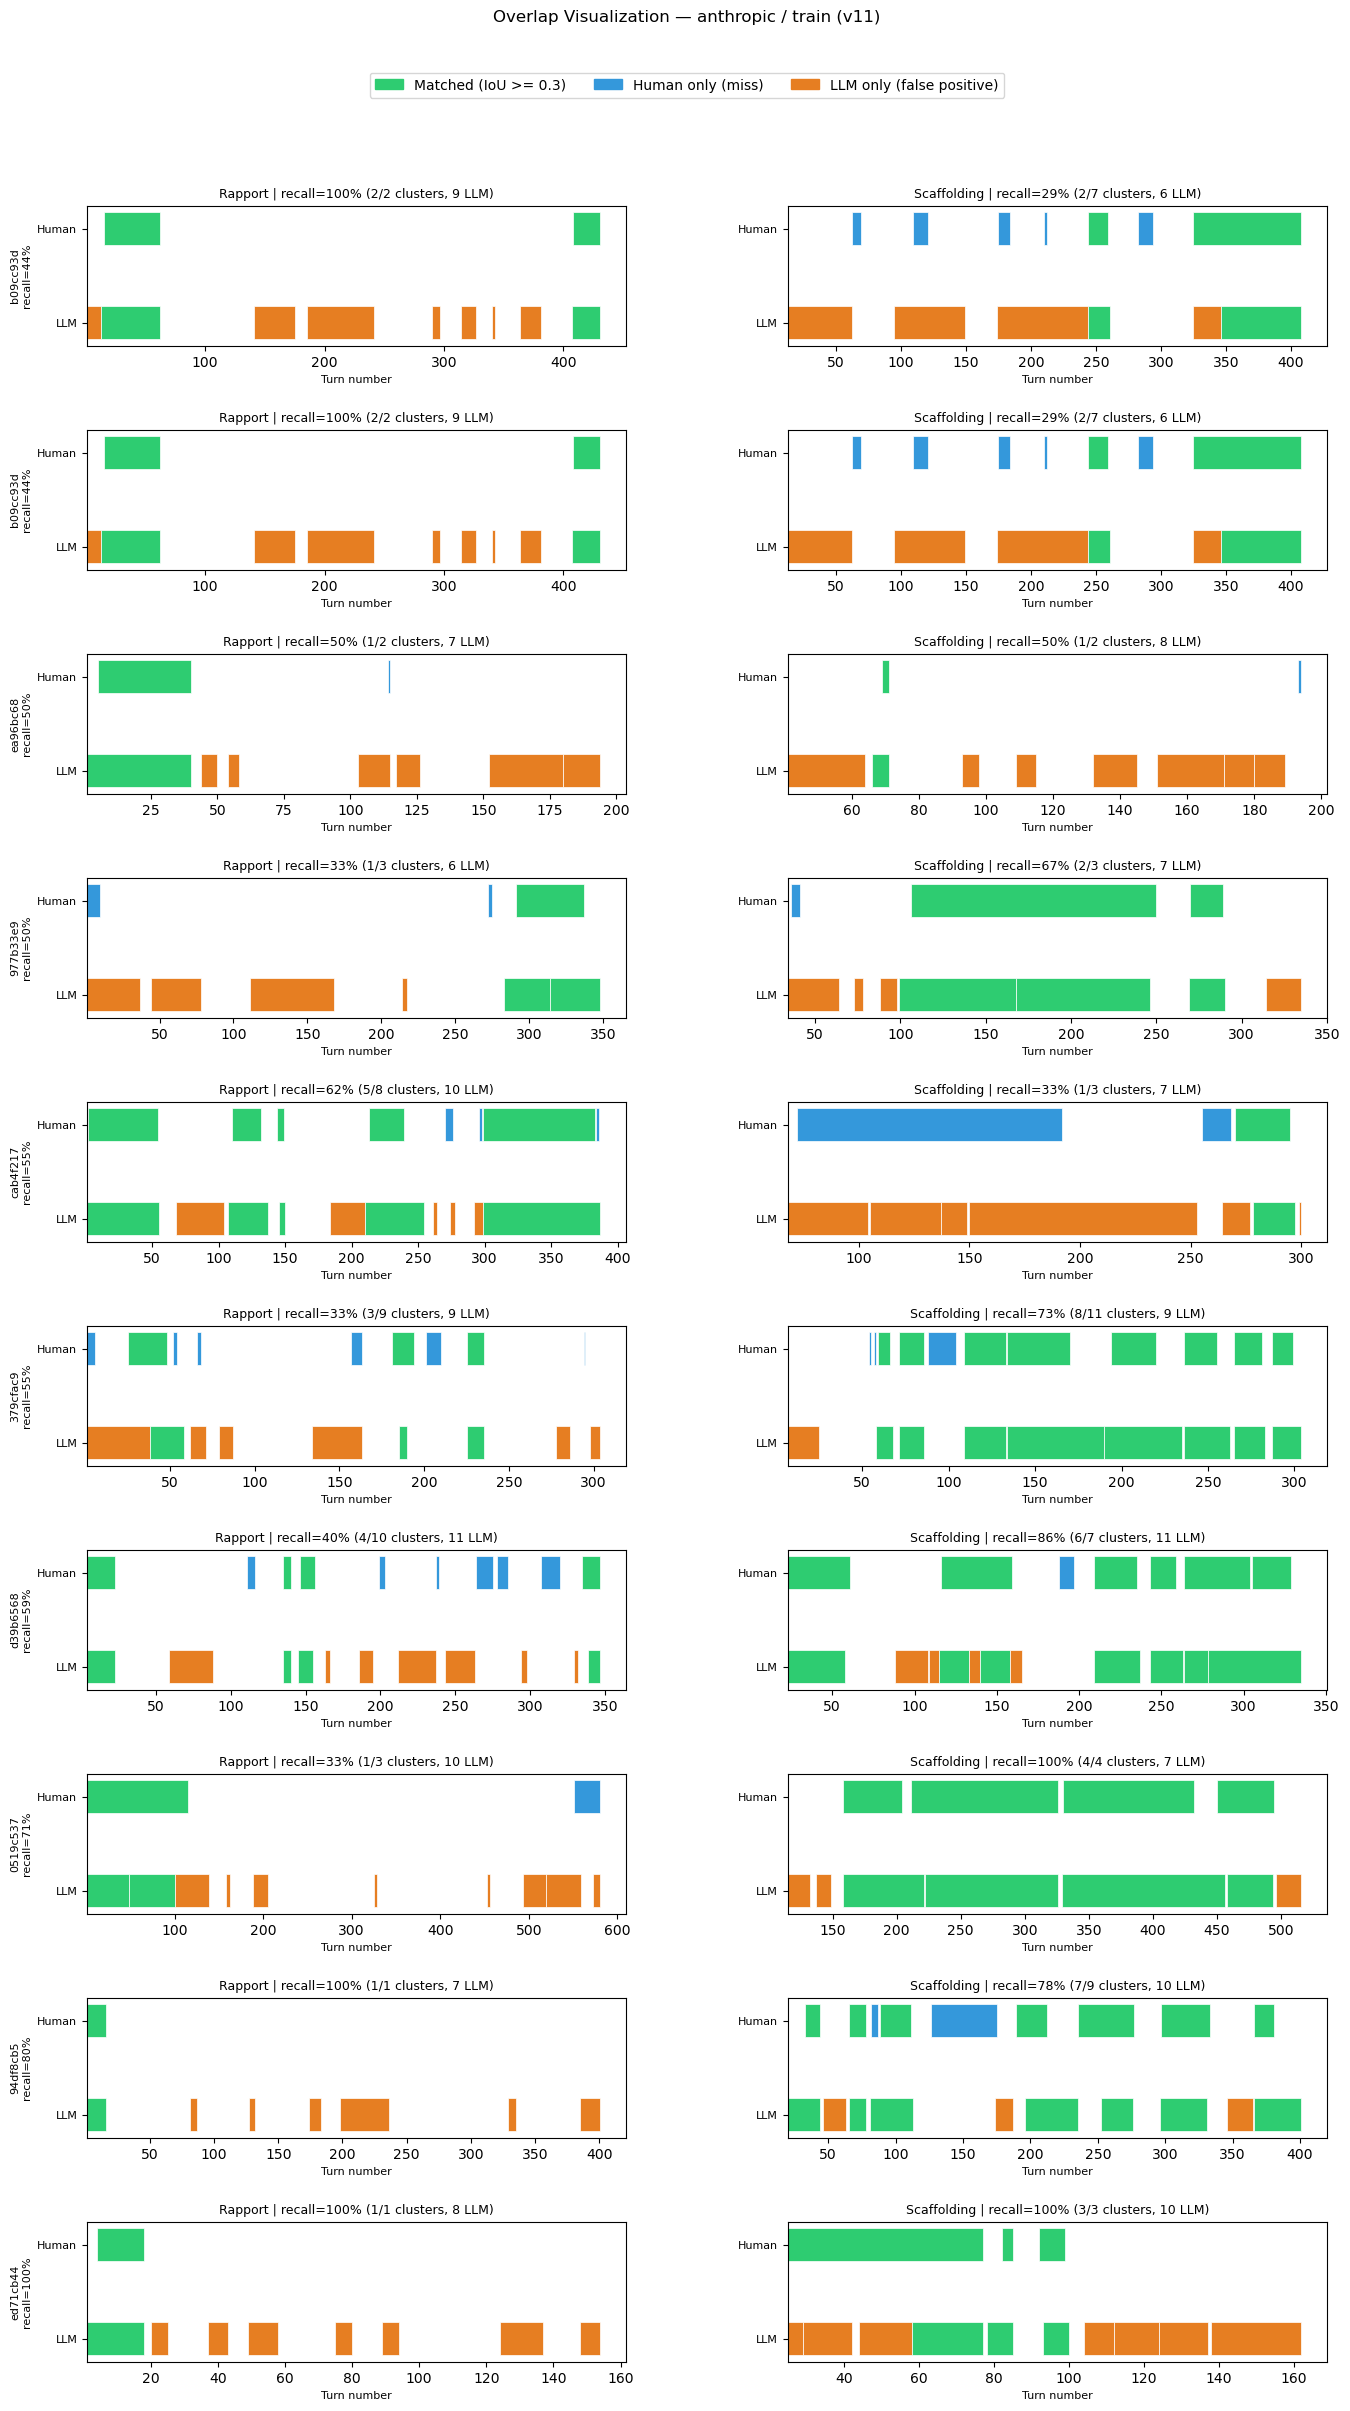

In [6]:
COLORS = {
    "matched":    "#2ecc71",
    "human_only": "#3498db",
    "llm_only":   "#e67e22",
}
IOU = 0.3
split = "train"
model_profile = "anthropic"

# Load anthropic test data
_split_ids = load_split_ids(split)
_gt_convs  = {cid: cd for cid, cd in ground_truth["conversations"].items()
              if cid in _split_ids}
_llm_moments = load_detections_as_moments(VERSION, profile=model_profile, split=split)

_eval_ids      = (set(_gt_convs.keys()) & set(_llm_moments.keys())) - EXAMPLE_CONV_IDS
_human_by_conv = {cid: _gt_convs[cid]["key_moments"] for cid in _eval_ids}
_llm_by_conv   = {cid: _llm_moments.get(cid, [])     for cid in _eval_ids}

# Sample 5 conversations spanning the combined recall spectrum,
# restricted to those with human clusters in BOTH annotation types
_metrics  = compute_detection_metrics(_human_by_conv, _llm_by_conv)

def _has_clusters_for_all_types(cid):
    return all(
        merge_overlapping_ranges([m for m in _human_by_conv.get(cid, [])
                                  if m.get("annotation_type") == ann_type])
        for ann_type in ANN_TYPES
    )

_per_conv = {cid: v for cid, v in _metrics["per_conversation"].items()
             if v["clusters"] > 0 and _has_clusters_for_all_types(cid)}
_sorted   = sorted(_per_conv.items(), key=lambda x: x[1]["recall"])
n         = len(_sorted)
k = 10
selected = [_sorted[i * (n - 1) // (k - 1)] for i in range(k)]

# ── Plot: 5 rows (conversations) × 2 cols (rapport | scaffolding) ──────────
fig, axes = plt.subplots(len(selected), 2,
                         figsize=(16, 2.8 * len(selected)),
                         gridspec_kw={"hspace": 0.6, "wspace": 0.3})

for row, (conv_id, conv_m) in enumerate(selected):
    for col, ann_type in enumerate(ANN_TYPES):
        ax = axes[row, col]
        human_raw = [m for m in _human_by_conv.get(conv_id, [])
                     if m.get("annotation_type") == ann_type]
        llm_raw   = [m for m in _llm_by_conv.get(conv_id, [])
                     if m.get("annotation_type") == ann_type]
        clusters  = merge_overlapping_ranges(human_raw)
        y_h, y_l, bh = 1.0, 0.0, 0.35

        for cl in clusters:
            cr   = (cl["turn_start"], cl["turn_end"])
            best = max((compute_iou(cr, (l["turn_start"], l["turn_end"]))
                        for l in llm_raw), default=0)
            color = COLORS["matched"] if best >= IOU else COLORS["human_only"]
            ax.barh(y_h, cl["turn_end"] - cl["turn_start"] + 1, left=cl["turn_start"],
                    height=bh, color=color, edgecolor="white", linewidth=0.5)

        for l in llm_raw:
            lr   = (l["turn_start"], l["turn_end"])
            best = max((compute_iou(lr, (cl["turn_start"], cl["turn_end"]))
                        for cl in clusters), default=0)
            color = COLORS["matched"] if best >= IOU else COLORS["llm_only"]
            ax.barh(y_l, l["turn_end"] - l["turn_start"] + 1, left=l["turn_start"],
                    height=bh, color=color, edgecolor="white", linewidth=0.5)

        n_clusters = len(clusters)
        n_found    = sum(1 for cl in clusters
                         if max((compute_iou((cl["turn_start"], cl["turn_end"]),
                                             (l["turn_start"], l["turn_end"]))
                                  for l in llm_raw), default=0) >= IOU)
        recall = n_found / n_clusters if n_clusters else 0

        ax.set_yticks([y_l, y_h])
        ax.set_yticklabels(["LLM", "Human"], fontsize=8)
        ax.set_xlabel("Turn number", fontsize=8)
        ax.set_title(f"{ann_type.capitalize()} | recall={recall:.0%} "
                     f"({n_found}/{n_clusters} clusters, {len(llm_raw)} LLM)", fontsize=9)
        if col == 0:
            ax.set_ylabel(f"{conv_id[:8]}\nrecall={conv_m['recall']:.0%}", fontsize=8)

patches = [
    mpatches.Patch(color=COLORS["matched"],    label="Matched (IoU >= 0.3)"),
    mpatches.Patch(color=COLORS["human_only"], label="Human only (miss)"),
    mpatches.Patch(color=COLORS["llm_only"],   label="LLM only (false positive)"),
]
fig.legend(handles=patches, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=3)
plt.suptitle(f"Overlap Visualization — {model_profile} / {split} (v11)", fontsize=12, y=0.95)
plt.tight_layout()
plt.show()

# Annotation

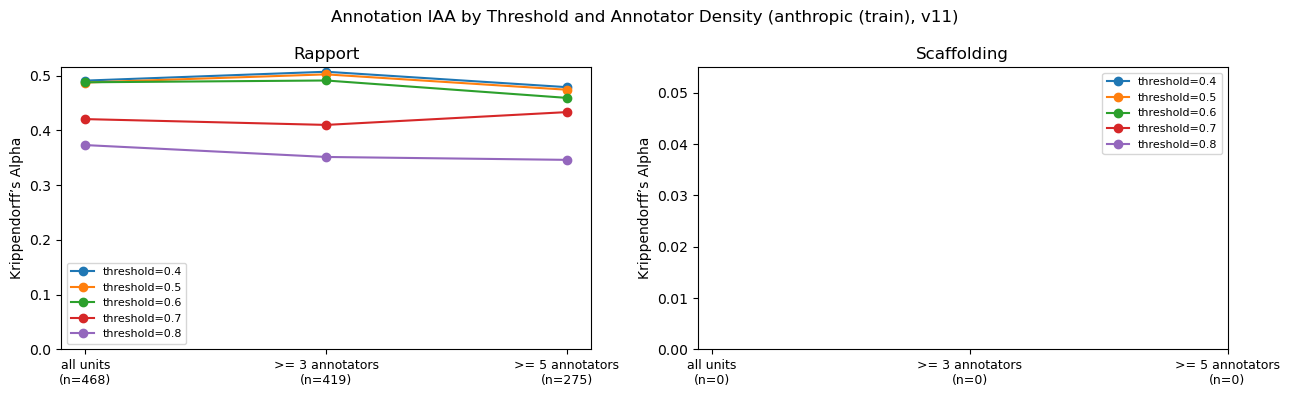

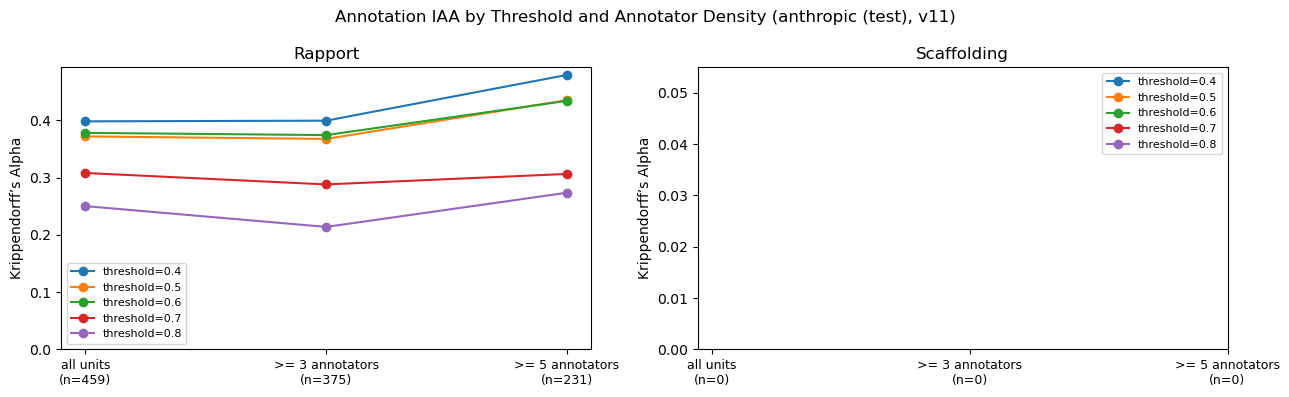

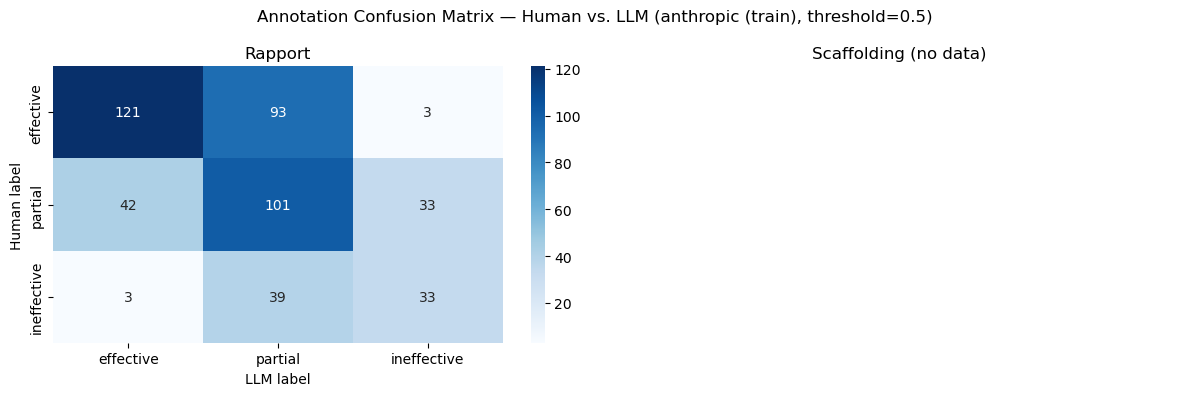

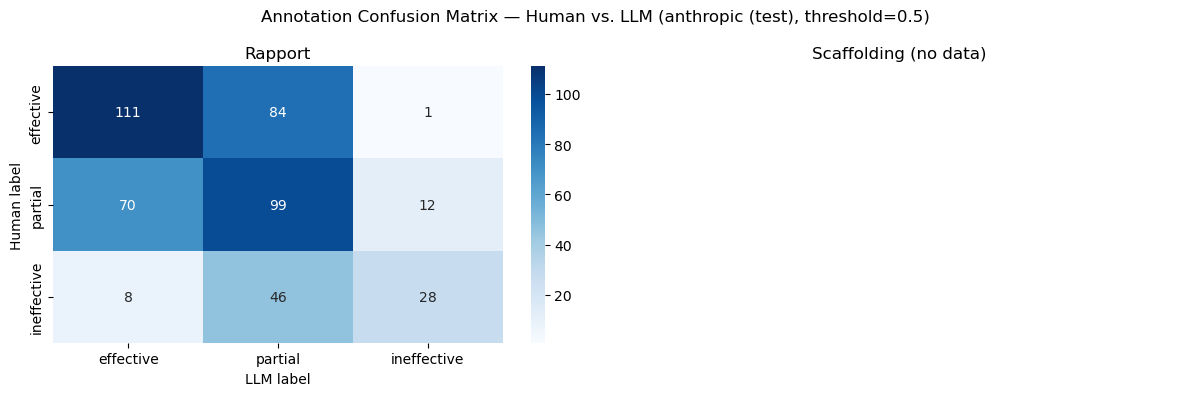

In [ ]:
from annotator.core.storage import load_annotator_result

ALPHA_THRESHOLDS = [0.4, 0.5, 0.6, 0.7, 0.8]
DENSITY_KEYS = [
    ("all units",          "iaa_by_threshold"),
    (">= 3 annotators",    "iaa_dense_by_threshold"),
    (">= 5 annotators",    "iaa_dense5_by_threshold"),
]

# ── Load eval data ─────────────────────────────────────────────────────────
eval_runs = []
for split, filename in [("train", "eval_annotations.json"), ("test", "eval_annotations_test.json")]:
    data = load_annotator_result(VERSION, filename)
    if data is not None:
        eval_runs.append((f"anthropic ({split})", data))
    else:
        print(f"No eval data for {split} — skipping")

# ── Alpha line plots ───────────────────────────────────────────────────────
PALETTE = sns.color_palette("tab10", len(ALPHA_THRESHOLDS))

for run_label, run_data in eval_runs:
    fig, axes = plt.subplots(1, len(ANN_TYPES), figsize=(13, 4), sharey=False)
    for ax, ann_type in zip(axes, ANN_TYPES):
        by_type = run_data.get("by_type", {}).get(ann_type, {})

        # Build x-tick labels with n_units (constant across thresholds per density level)
        x_labels = []
        for base_label, density_key in DENSITY_KEYS:
            first_entry = next(iter(by_type.get(density_key, {}).values()), {})
            n = first_entry.get("n_units", "?")
            x_labels.append(f"{base_label}\n(n={n})")

        x = range(len(x_labels))

        for i, thresh in enumerate(ALPHA_THRESHOLDS):
            alphas = []
            for _, density_key in DENSITY_KEYS:
                entry = by_type.get(density_key, {}).get(str(thresh), {})
                alphas.append(entry.get("alpha") or float("nan"))
            ax.plot(x, alphas, marker="o", color=PALETTE[i], label=f"threshold={thresh}")

        ax.set_xticks(list(x))
        ax.set_xticklabels(x_labels, fontsize=9)
        ax.set_ylabel("Krippendorff’s Alpha")
        ax.set_title(f"{ann_type.capitalize()}")
        ax.legend(fontsize=8)
        ax.set_ylim(bottom=0)

    plt.suptitle(f"Annotation IAA by Threshold and Annotator Density ({run_label}, {VERSION})", fontsize=12)
    plt.tight_layout()
    plt.show()

# ── Confusion matrix heatmaps ──────────────────────────────────────────────
LABELS = ["effective", "partial", "ineffective"]

for run_label, run_data in eval_runs:
    fig, axes = plt.subplots(1, len(ANN_TYPES), figsize=(12, 4))
    for ax, ann_type in zip(axes, ANN_TYPES):
        by_type = run_data.get("by_type", {}).get(ann_type, {})
        confusion = by_type.get("iaa", {}).get("confusion", {})

        if not confusion:
            ax.set_title(f"{ann_type.capitalize()} (no data)")
            ax.axis("off")
            continue

        matrix = []
        for human_label in LABELS:
            row = [confusion.get(human_label, {}).get(llm_label, 0) for llm_label in LABELS]
            matrix.append(row)
        df_cm = pd.DataFrame(matrix, index=LABELS, columns=LABELS)

        sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=LABELS, yticklabels=LABELS)
        ax.set_xlabel("LLM label")
        ax.set_ylabel("Human label")
        ax.set_title(f"{ann_type.capitalize()}")

    plt.suptitle(f"Annotation Confusion Matrix — Human vs. LLM ({run_label}, threshold=0.5)", fontsize=12)
    plt.tight_layout()
    plt.show()
